# **Assignment 07: Stable Diffusion 3.5**

**Available:** Oct 9, 2025 3:00pm until Oct 16, 2025 11:59pm

**Details**
- https://huggingface.co/datasets/Gustavosta/Stable-Diffusion-Prompts/viewer/default/test?views%5B%5D=test
    - Go to the "People" section in the webcourse​
    - If you are the first student, for example, you will take the first 10 prompts from above link, second student will take the 11-20th prompts in the list and so on​
- Run Stable Diffusion 3.5 and compare with SDXL and SDXL Turbo from the last assignment
- Compare all 3 models with these 2 metrics
    - FID​
    - Speed ​
- Report due 10/16

## **Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import datasets
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None


# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")


Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [2]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available: False
CUDA version: 12.8
Number of GPUs detected: 2

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

GPU 1:
  Name: NVIDIA RTX A6000
  Total Memory: 47.53 GB
  Multi-processor count: 84
  Compute Capability: 8.6

Using GPU 1: NVIDIA RTX A6000
Selected device: cuda:1


In [3]:
# Function to clear memory for both CUDA and MPS
def clear_memory():
    """Clear CPU and GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"Cleared memory. Current CPU memory usage: {get_memory_usage():.2f} MB, GPU memory usage: {get_gpu_memory_usage():.2f} MB")

In [4]:
# Stable Diffusion Prompts:

prompt_list = [
    
"a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws",
"a character portrait of a cyborg super saiyan in the style of moebius in the style of yoji shinkawa trending on artstation deviantart pinterest detailed realistic hd 8 k high resolution",
"big hand holding skull and bones, illustrated by Simon Stålenhag and Gaston Bussiere, intricate, ultra detailed, photorealistic, trending on artstation",
"Her huge ominous glowing blue eyes staring into my soul , perfect eyes, soft pale white skin, intricate stunning highly detailed, agostino arrivabene, artgerm, twisted dark lucid dream, 8k portrait render, raven angel wings, swirling thick smoke , beautiful lighting, dark fantasy art, cgsociety",
"the prince of frost standing alone in his court, archfey, full - body portrait, fantasy, white hair, blue skin, wild eyebrows, young adult, elf, crown, hard edges, soft lighting, professional lighting, trending on artstation",
"male cottagecore snoop dogg, Calvin Cordozar Broadus Jr., intricate, swagger, highly detailed, digital painting, artstation, concept art, smooth, sharp, focus, illustration, art by artgerm and greg rutkowski and alphonse mucha",
"amazing lifelike award winning pencil illustration of bob dylan trending on art station artgerm greg rutkowski alphonse mucha cinematic",
"medium - shot vislor turlough played by mark strickson at age 1 8, beautiful, at the alien space pub bar counter, highly detailed, mood lighting, artstation, highly detailed digital painting, smooth, global illumination, fantasy art by greg rutkowsky, karl spitzweg, leyendecker",
"portal to the multiverse of infinite horror with freakish spider creatures leaking out by laurie greasley digital art, highly detailed, intricate, sharp focus, trending on artstation hq, deviantart, octane render, bump map, pinterest, unreal engine 5, 4 k uhd image",
"concept art of fractal shaped spaceship by Michal Klimczak, high detail, artstation CG society"

]

## **Import Stable Diffusion 3.5 and Run Prompts**

In [5]:
# Import SD 3.5
# Source: https://huggingface.co/stabilityai/stable-diffusion-3.5-large

import torch
from diffusers import StableDiffusion3Pipeline

pipe = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-large", torch_dtype=torch.bfloat16)
pipe = pipe.to(device)


Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


  0%|          | 0/28 [00:00<?, ?it/s]

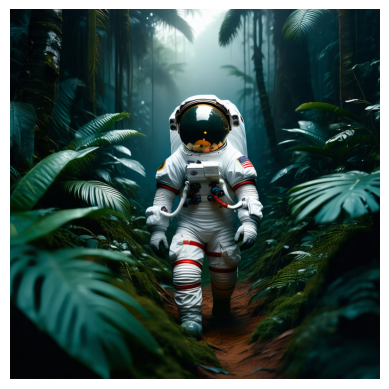

Generating image for prompt: a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 0_sdxl_3_5_a_girl_smiling__Tristan_Eaton__victo_ngai__artgerm.png (generation time: 22.52 sec)


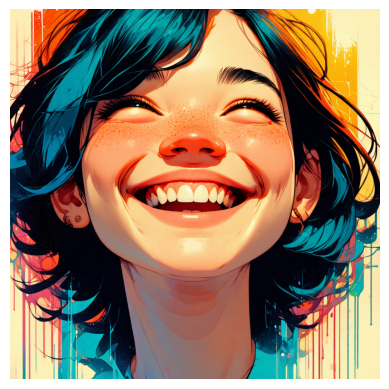

Generating image for prompt: a character portrait of a cyborg super saiyan in the style of moebius in the style of yoji shinkawa trending on artstation deviantart pinterest detailed realistic hd 8 k high resolution


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 1_sdxl_3_5_a_character_portrait_of_a_cyborg_super_saiyan_in_t.png (generation time: 22.91 sec)


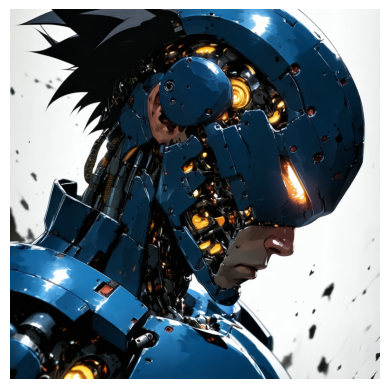

Generating image for prompt: big hand holding skull and bones, illustrated by Simon Stålenhag and Gaston Bussiere, intricate, ultra detailed, photorealistic, trending on artstation


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 2_sdxl_3_5_big_hand_holding_skull_and_bones__illustrated_by_S.png (generation time: 23.17 sec)


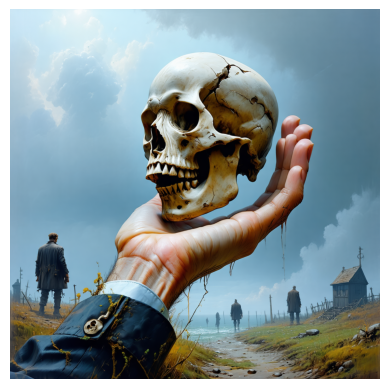

Generating image for prompt: Her huge ominous glowing blue eyes staring into my soul , perfect eyes, soft pale white skin, intricate stunning highly detailed, agostino arrivabene, artgerm, twisted dark lucid dream, 8k portrait render, raven angel wings, swirling thick smoke , beautiful lighting, dark fantasy art, cgsociety


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 3_sdxl_3_5_Her_huge_ominous_glowing_blue_eyes_staring_into_my.png (generation time: 23.32 sec)


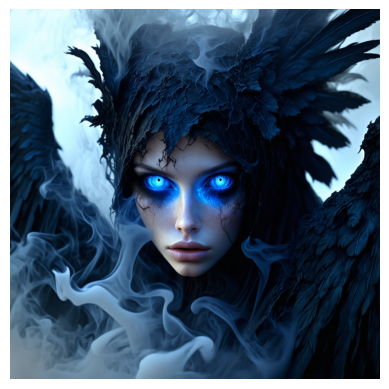

Generating image for prompt: the prince of frost standing alone in his court, archfey, full - body portrait, fantasy, white hair, blue skin, wild eyebrows, young adult, elf, crown, hard edges, soft lighting, professional lighting, trending on artstation


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 4_sdxl_3_5_the_prince_of_frost_standing_alone_in_his_court__a.png (generation time: 23.41 sec)


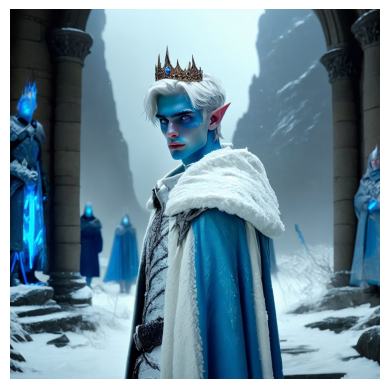

Generating image for prompt: male cottagecore snoop dogg, Calvin Cordozar Broadus Jr., intricate, swagger, highly detailed, digital painting, artstation, concept art, smooth, sharp, focus, illustration, art by artgerm and greg rutkowski and alphonse mucha


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 5_sdxl_3_5_male_cottagecore_snoop_dogg__Calvin_Cordozar_Broad.png (generation time: 23.50 sec)


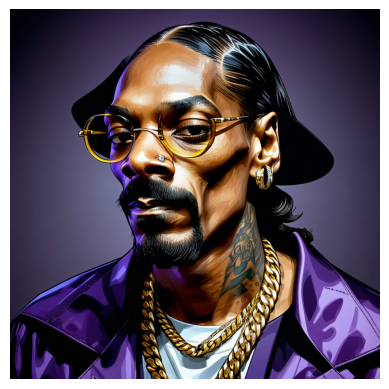

Generating image for prompt: amazing lifelike award winning pencil illustration of bob dylan trending on art station artgerm greg rutkowski alphonse mucha cinematic


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 6_sdxl_3_5_amazing_lifelike_award_winning_pencil_illustration.png (generation time: 23.57 sec)


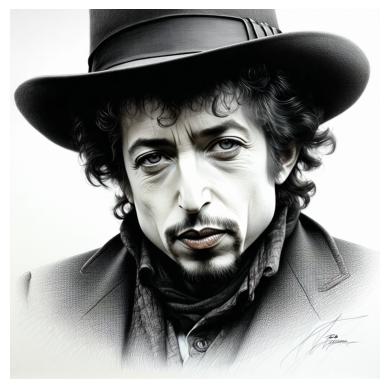

Generating image for prompt: medium - shot vislor turlough played by mark strickson at age 1 8, beautiful, at the alien space pub bar counter, highly detailed, mood lighting, artstation, highly detailed digital painting, smooth, global illumination, fantasy art by greg rutkowsky, karl spitzweg, leyendecker


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 7_sdxl_3_5_medium___shot_vislor_turlough_played_by_mark_stric.png (generation time: 23.61 sec)


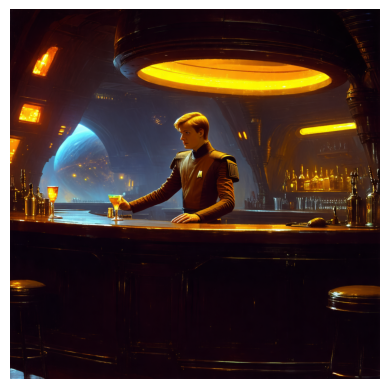

Generating image for prompt: portal to the multiverse of infinite horror with freakish spider creatures leaking out by laurie greasley digital art, highly detailed, intricate, sharp focus, trending on artstation hq, deviantart, octane render, bump map, pinterest, unreal engine 5, 4 k uhd image


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 8_sdxl_3_5_portal_to_the_multiverse_of_infinite_horror_with_f.png (generation time: 23.64 sec)


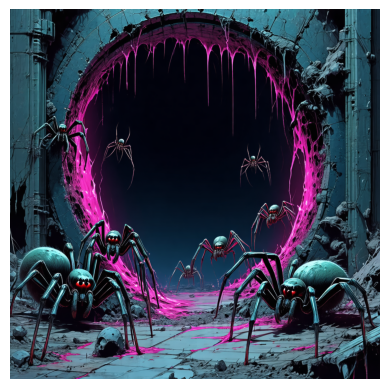

Generating image for prompt: concept art of fractal shaped spaceship by Michal Klimczak, high detail, artstation CG society


  0%|          | 0/28 [00:00<?, ?it/s]

Saved image to 9_sdxl_3_5_concept_art_of_fractal_shaped_spaceship_by_Michal_.png (generation time: 23.64 sec)


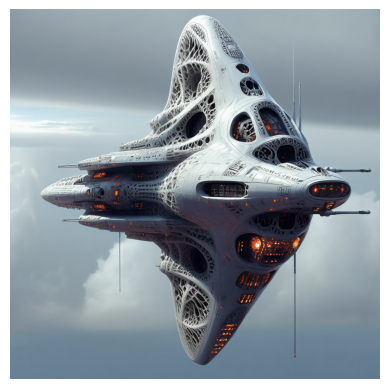

Logs saved to logs/sdxl_3_5_inference_logs.csv


In [6]:
# Run Prompts

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

plt.imshow(image)
image.save("data/test_image.png")
plt.axis('off')  # Hide axes
plt.show()

logs = []

for idx,prompt in enumerate(prompt_list):
    print(f"Generating image for prompt: {prompt}")
    start_time = time.time()
    image = pipe(prompt=prompt).images[0]
    duration = time.time() - start_time

    # Save each image with a unique filename based on the prompt
    safe_prompt = "".join(c if c.isalnum() else "_" for c in prompt)[:50]  # Sanitize
    filename = f"{idx}_sdxl_3_5_{safe_prompt}.png"
    image.save(f"data/{filename}")
    print(f"Saved image to {filename} (generation time: {duration:.2f} sec)")
    
    # Display the image
    plt.imshow(image)
    plt.axis('off')  # Hide axes
    plt.show()

    # Log info
    logs.append({
        "idx": idx,
        "prompt": prompt,
        "filename": filename,
        "duration_sec": duration
    })

# Save logs to CSV
df_logs = pd.DataFrame(logs)
df_logs.to_csv("logs/sdxl_3_5_inference_logs.csv", index=False)
print("Logs saved to logs/sdxl_3_5_inference_logs.csv")

In [7]:
# Delete Model
del pipe
clear_memory()

Cleared memory. Current CPU memory usage: 2383.92 MB, GPU memory usage: 0.00 MB


## Compare Results from SDXL_Turbo, SDXL and SD_3.5 using Inference Times and FID Scores

In [8]:
# Compare Time from Logs

# Read the log files - all three are in the logs directory
sdxl_base_logs = pd.read_csv("logs/sdxl_base_inference_logs.csv")
sdxl_turbo_logs = pd.read_csv("logs/sdxl_turbo_inference_logs.csv")
sdxl_3_5_logs = pd.read_csv("logs/sdxl_3_5_inference_logs.csv")

# Create a comparison table
comparison_data = []

for i in range(len(sdxl_base_logs)):
    base_row = sdxl_base_logs.iloc[i]
    turbo_row = sdxl_turbo_logs.iloc[i]
    sd_3_5_row = sdxl_3_5_logs.iloc[i]
    
    comparison_data.append({
        'Prompt_ID': i,
        'Prompt': base_row['prompt'],
        'SDXL_Base_Time_sec': round(base_row['duration_sec'], 2),
        'SDXL_Turbo_Time_sec': round(turbo_row['duration_sec'], 2),
        'SD_3_5_Time_sec': round(sd_3_5_row['duration_sec'], 2),
        'Turbo_vs_Base_Speedup': round(base_row['duration_sec'] / turbo_row['duration_sec'], 2),
        'SD_3_5_vs_Base_Speedup': round(base_row['duration_sec'] / sd_3_5_row['duration_sec'], 2),
        'SD_3_5_vs_Turbo_Speedup': round(turbo_row['duration_sec'] / sd_3_5_row['duration_sec'], 2)
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("=== Generation Time Comparison ===\n")
print(comparison_df.to_string(index=False))

# Calculate summary statistics
print(f"\n=== Summary Statistics ===")
print(f"SDXL Base - Average generation time: {comparison_df['SDXL_Base_Time_sec'].mean():.2f} seconds")
print(f"SDXL Base - Total generation time: {comparison_df['SDXL_Base_Time_sec'].sum():.2f} seconds")
print(f"SDXL Turbo - Average generation time: {comparison_df['SDXL_Turbo_Time_sec'].mean():.2f} seconds") 
print(f"SDXL Turbo - Total generation time: {comparison_df['SDXL_Turbo_Time_sec'].sum():.2f} seconds")
print(f"SD 3.5 - Average generation time: {comparison_df['SD_3_5_Time_sec'].mean():.2f} seconds")
print(f"SD 3.5 - Total generation time: {comparison_df['SD_3_5_Time_sec'].sum():.2f} seconds")

print(f"\n=== Speed Comparison ===")
print(f"SDXL Turbo vs SDXL Base: {comparison_df['Turbo_vs_Base_Speedup'].mean():.2f}x faster")
print(f"SD 3.5 vs SDXL Base: {comparison_df['SD_3_5_vs_Base_Speedup'].mean():.2f}x faster")
print(f"SD 3.5 vs SDXL Turbo: {comparison_df['SD_3_5_vs_Turbo_Speedup'].mean():.2f}x faster")

# Save the comparison table
comparison_df.to_csv("logs/three_model_comparison_table.csv", index=False)
print(f"\nThree-model comparison table saved to logs/three_model_comparison_table.csv")

=== Generation Time Comparison ===

 Prompt_ID                                                                                                                                                                                                                                                                                                  Prompt  SDXL_Base_Time_sec  SDXL_Turbo_Time_sec  SD_3_5_Time_sec  Turbo_vs_Base_Speedup  SD_3_5_vs_Base_Speedup  SD_3_5_vs_Turbo_Speedup
         0                                                                                                                                                                                                                                   a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws               39.88                 2.94            22.52                  13.56                    1.77                     0.13
         1                                                                                

In [9]:
# Install pytorch-fid for FID calculation
%pip install pytorch-fid

# Import necessary libraries for FID calculation
import os
import glob
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from scipy import linalg
from torch.utils.data import Dataset, DataLoader

# Custom dataset for loading images
class ImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Load pre-trained Inception v3 model for feature extraction
def load_inception_model(device):
    """Load and prepare Inception v3 model for FID calculation"""
    inception = models.inception_v3(pretrained=True, transform_input=False)
    inception.fc = nn.Identity()  # Remove final classification layer
    inception.eval()
    inception.to(device)
    return inception

# Extract features using Inception v3
def extract_features(model, dataloader, device):
    """Extract features from images using Inception v3"""
    features = []
    model.eval()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting features"):
            batch = batch.to(device)
            # Inception v3 expects 299x299 images
            if batch.shape[-1] != 299:
                batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            
            feat = model(batch)
            features.append(feat.cpu().numpy())
    
    return np.concatenate(features, axis=0)

# Calculate FID score
def calculate_fid(features1, features2):
    """Calculate FID score between two sets of features"""
    # Calculate mean and covariance for both feature sets
    mu1, sigma1 = features1.mean(axis=0), np.cov(features1, rowvar=False)
    mu2, sigma2 = features2.mean(axis=0), np.cov(features2, rowvar=False)
    
    # Calculate sum squared difference between means
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    
    # Calculate sqrt of product between covariances
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    
    # Check for imaginary numbers and take real part
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # Calculate FID
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

# Prepare data transforms for Inception v3
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Setting up FID calculation...")

# Get image paths for all three models
data_dir = "data"
sdxl_base_images = sorted(glob.glob(os.path.join(data_dir, "*_sdxl_*.png")))
sdxl_turbo_images = sorted(glob.glob(os.path.join(data_dir, "*_sdxl_turbo_*.png")))
sd_3_5_images = sorted(glob.glob(os.path.join(data_dir, "*_sdxl_3_5_*.png")))

print(f"Found {len(sdxl_base_images)} SDXL Base images")
print(f"Found {len(sdxl_turbo_images)} SDXL Turbo images")
print(f"Found {len(sd_3_5_images)} SD 3.5 images")

# Create datasets and dataloaders
base_dataset = ImageDataset(sdxl_base_images, transform=transform)
turbo_dataset = ImageDataset(sdxl_turbo_images, transform=transform)
sd_3_5_dataset = ImageDataset(sd_3_5_images, transform=transform)

base_dataloader = DataLoader(base_dataset, batch_size=4, shuffle=False)
turbo_dataloader = DataLoader(turbo_dataset, batch_size=4, shuffle=False)
sd_3_5_dataloader = DataLoader(sd_3_5_dataset, batch_size=4, shuffle=False)

# Load Inception model
print("Loading Inception v3 model...")
inception_model = load_inception_model(device)

# Extract features for all three sets of images
print("Extracting features from SDXL Base images...")
base_features = extract_features(inception_model, base_dataloader, device)

print("Extracting features from SDXL Turbo images...")
turbo_features = extract_features(inception_model, turbo_dataloader, device)

print("Extracting features from SD 3.5 images...")
sd_3_5_features = extract_features(inception_model, sd_3_5_dataloader, device)

# Calculate all pairwise FID scores
print("Calculating FID scores...")
fid_base_vs_turbo = calculate_fid(base_features, turbo_features)
fid_base_vs_sd_3_5 = calculate_fid(base_features, sd_3_5_features)
fid_turbo_vs_sd_3_5 = calculate_fid(turbo_features, sd_3_5_features)

print(f"\n=== FID Score Results ===")
print(f"FID Score (SDXL Base vs SDXL Turbo): {fid_base_vs_turbo:.4f}")
print(f"FID Score (SDXL Base vs SD 3.5): {fid_base_vs_sd_3_5:.4f}")
print(f"FID Score (SDXL Turbo vs SD 3.5): {fid_turbo_vs_sd_3_5:.4f}")

# Function to assess quality based on FID score
def assess_quality(fid_score):
    if fid_score < 10:
        return "Excellent - Very similar image quality and distribution"
    elif fid_score < 25:
        return "Good - Similar image quality with some differences"
    elif fid_score < 50:
        return "Moderate - Noticeable differences in image quality"
    else:
        return "Poor - Significant differences in image quality"

print(f"\n=== Quality Assessments ===")
print(f"SDXL Base vs SDXL Turbo: {assess_quality(fid_base_vs_turbo)}")
print(f"SDXL Base vs SD 3.5: {assess_quality(fid_base_vs_sd_3_5)}")
print(f"SDXL Turbo vs SD 3.5: {assess_quality(fid_turbo_vs_sd_3_5)}")

# Save comprehensive FID results
fid_results = {
    'SDXL_Base_Images': len(sdxl_base_images),
    'SDXL_Turbo_Images': len(sdxl_turbo_images),
    'SD_3_5_Images': len(sd_3_5_images),
    'FID_Base_vs_Turbo': fid_base_vs_turbo,
    'FID_Base_vs_SD_3_5': fid_base_vs_sd_3_5,
    'FID_Turbo_vs_SD_3_5': fid_turbo_vs_sd_3_5,
    'Quality_Assessment_Base_vs_Turbo': assess_quality(fid_base_vs_turbo),
    'Quality_Assessment_Base_vs_SD_3_5': assess_quality(fid_base_vs_sd_3_5),
    'Quality_Assessment_Turbo_vs_SD_3_5': assess_quality(fid_turbo_vs_sd_3_5)
}

import json
with open('logs/comprehensive_fid_results.json', 'w') as f:
    json.dump(fid_results, f, indent=2)

print(f"\nComprehensive FID results saved to logs/comprehensive_fid_results.json")

# Clean up memory
del inception_model
clear_memory()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.
Setting up FID calculation...
Found 30 SDXL Base images
Found 10 SDXL Turbo images
Found 10 SD 3.5 images
Loading Inception v3 model...


/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting features from SDXL Base images...


Extracting features:   0%|          | 0/8 [00:00<?, ?it/s]

Extracting features from SDXL Turbo images...


Extracting features:   0%|          | 0/3 [00:00<?, ?it/s]

Extracting features from SD 3.5 images...


Extracting features:   0%|          | 0/3 [00:00<?, ?it/s]

Calculating FID scores...

=== FID Score Results ===
FID Score (SDXL Base vs SDXL Turbo): 156.2088
FID Score (SDXL Base vs SD 3.5): 144.3911
FID Score (SDXL Turbo vs SD 3.5): 303.6248

=== Quality Assessments ===
SDXL Base vs SDXL Turbo: Poor - Significant differences in image quality
SDXL Base vs SD 3.5: Poor - Significant differences in image quality
SDXL Turbo vs SD 3.5: Poor - Significant differences in image quality

Comprehensive FID results saved to logs/comprehensive_fid_results.json
Cleared memory. Current CPU memory usage: 2442.42 MB, GPU memory usage: 0.00 MB


In [10]:
# Comprehensive Three-Model Comparison Analysis
print("=== COMPREHENSIVE THREE-MODEL COMPARISON ===\n")

# Load timing comparison data
timing_df = pd.read_csv("logs/three_model_comparison_table.csv")

# Load FID results
with open('logs/comprehensive_fid_results.json', 'r') as f:
    fid_data = json.load(f)

print("1. SPEED COMPARISON:")
print(f"   • SDXL Base average time: {timing_df['SDXL_Base_Time_sec'].mean():.2f} seconds")
print(f"   • SDXL Turbo average time: {timing_df['SDXL_Turbo_Time_sec'].mean():.2f} seconds")
print(f"   • SD 3.5 average time: {timing_df['SD_3_5_Time_sec'].mean():.2f} seconds")
print(f"   • SDXL Turbo vs Base speedup: {timing_df['Turbo_vs_Base_Speedup'].mean():.2f}x faster")
print(f"   • SD 3.5 vs Base speedup: {timing_df['SD_3_5_vs_Base_Speedup'].mean():.2f}x faster")
print(f"   • SD 3.5 vs Turbo speedup: {timing_df['SD_3_5_vs_Turbo_Speedup'].mean():.2f}x faster\n")

print("2. IMAGE QUALITY COMPARISON (FID Scores):")
print(f"   • SDXL Base vs SDXL Turbo: {fid_data['FID_Base_vs_Turbo']:.4f}")
print(f"     Assessment: {fid_data['Quality_Assessment_Base_vs_Turbo']}")
print(f"   • SDXL Base vs SD 3.5: {fid_data['FID_Base_vs_SD_3_5']:.4f}")
print(f"     Assessment: {fid_data['Quality_Assessment_Base_vs_SD_3_5']}")
print(f"   • SDXL Turbo vs SD 3.5: {fid_data['FID_Turbo_vs_SD_3_5']:.4f}")
print(f"     Assessment: {fid_data['Quality_Assessment_Turbo_vs_SD_3_5']}\n")

print("3. MODEL RANKING:")

# Create ranking based on speed (lower time = better rank)
speed_ranking = [
    ('SDXL Base', timing_df['SDXL_Base_Time_sec'].mean()),
    ('SDXL Turbo', timing_df['SDXL_Turbo_Time_sec'].mean()),
    ('SD 3.5', timing_df['SD_3_5_Time_sec'].mean())
]
speed_ranking.sort(key=lambda x: x[1])

print("   Speed Ranking (fastest to slowest):")
for i, (model, time) in enumerate(speed_ranking, 1):
    print(f"   {i}. {model}: {time:.2f} seconds")

# Quality ranking based on FID vs SDXL Base (lower FID = better quality)
quality_vs_base = [
    ('SDXL Turbo', fid_data['FID_Base_vs_Turbo']),
    ('SD 3.5', fid_data['FID_Base_vs_SD_3_5'])
]
quality_vs_base.sort(key=lambda x: x[1])

print(f"\n   Quality Ranking (compared to SDXL Base - lower FID is better):")
print(f"   1. SDXL Base: 0.0000 (reference)")
for i, (model, fid) in enumerate(quality_vs_base, 2):
    print(f"   {i}. {model}: {fid:.4f}")

print("\n4. TRADE-OFF ANALYSIS:")

# Analyze each model's trade-offs
turbo_speedup = timing_df['Turbo_vs_Base_Speedup'].mean()
turbo_fid = fid_data['FID_Base_vs_Turbo']

sd35_speedup = timing_df['SD_3_5_vs_Base_Speedup'].mean()
sd35_fid = fid_data['FID_Base_vs_SD_3_5']

print(f"   • SDXL Turbo: {turbo_speedup:.2f}x faster with FID {turbo_fid:.2f}")
if turbo_fid < 25 and turbo_speedup > 3:
    turbo_assessment = "Excellent speed-quality trade-off"
elif turbo_fid < 50:
    turbo_assessment = "Good speed-quality trade-off"
else:
    turbo_assessment = "Speed comes with quality compromise"

print(f"     Assessment: {turbo_assessment}")

print(f"   • SD 3.5: {sd35_speedup:.2f}x speed change with FID {sd35_fid:.2f}")
if sd35_fid < 25:
    if sd35_speedup > 1:
        sd35_assessment = "Better quality with speed improvement"
    elif sd35_speedup > 0.8:
        sd35_assessment = "Better quality with similar speed"
    else:
        sd35_assessment = "Better quality but slower"
else:
    if sd35_speedup > 1:
        sd35_assessment = "Faster but with quality trade-off"
    else:
        sd35_assessment = "Slower with quality trade-off"

print(f"     Assessment: {sd35_assessment}")

print("\n5. RECOMMENDATIONS:")
fastest_model = speed_ranking[0][0]
best_quality_model = "SDXL Base" if min(fid_data['FID_Base_vs_Turbo'], fid_data['FID_Base_vs_SD_3_5']) > 25 else \
                   ("SDXL Turbo" if fid_data['FID_Base_vs_Turbo'] < fid_data['FID_Base_vs_SD_3_5'] else "SD 3.5")

print(f"   • For speed: Use {fastest_model}")
print(f"   • For quality: Use SDXL Base as reference")
print(f"   • Best balance: {best_quality_model} (considering speed-quality trade-off)")

# Create comprehensive summary table
summary_data = {
    'Model': ['SDXL Base', 'SDXL Turbo', 'SD 3.5'],
    'Avg_Time_sec': [
        f"{timing_df['SDXL_Base_Time_sec'].mean():.2f}",
        f"{timing_df['SDXL_Turbo_Time_sec'].mean():.2f}",
        f"{timing_df['SD_3_5_Time_sec'].mean():.2f}"
    ],
    'Speedup_vs_Base': [
        "1.00x (reference)",
        f"{timing_df['Turbo_vs_Base_Speedup'].mean():.2f}x",
        f"{timing_df['SD_3_5_vs_Base_Speedup'].mean():.2f}x"
    ],
    'FID_vs_Base': [
        "0.0000 (reference)",
        f"{fid_data['FID_Base_vs_Turbo']:.4f}",
        f"{fid_data['FID_Base_vs_SD_3_5']:.4f}"
    ],
    'Quality_Assessment': [
        "Reference",
        fid_data['Quality_Assessment_Base_vs_Turbo'].split(' - ')[0],
        fid_data['Quality_Assessment_Base_vs_SD_3_5'].split(' - ')[0]
    ]
}

summary_df = pd.DataFrame(summary_data)
print(f"\n=== COMPREHENSIVE SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

# Save comprehensive results
summary_df.to_csv("logs/final_three_model_comparison.csv", index=False)

# Also save detailed analysis
analysis_results = {
    'timing_analysis': {
        'sdxl_base_avg_time': timing_df['SDXL_Base_Time_sec'].mean(),
        'sdxl_turbo_avg_time': timing_df['SDXL_Turbo_Time_sec'].mean(),
        'sd_3_5_avg_time': timing_df['SD_3_5_Time_sec'].mean(),
        'turbo_vs_base_speedup': timing_df['Turbo_vs_Base_Speedup'].mean(),
        'sd35_vs_base_speedup': timing_df['SD_3_5_vs_Base_Speedup'].mean(),
        'sd35_vs_turbo_speedup': timing_df['SD_3_5_vs_Turbo_Speedup'].mean()
    },
    'fid_analysis': fid_data,
    'recommendations': {
        'fastest_model': fastest_model,
        'best_quality_reference': 'SDXL Base',
        'turbo_assessment': turbo_assessment,
        'sd35_assessment': sd35_assessment
    }
}

with open('logs/final_analysis_results.json', 'w') as f:
    json.dump(analysis_results, f, indent=2)

print(f"\nFinal analysis saved to:")
print(f"  • logs/final_three_model_comparison.csv")
print(f"  • logs/final_analysis_results.json")

=== COMPREHENSIVE THREE-MODEL COMPARISON ===

1. SPEED COMPARISON:
   • SDXL Base average time: 40.60 seconds
   • SDXL Turbo average time: 2.95 seconds
   • SD 3.5 average time: 23.33 seconds
   • SDXL Turbo vs Base speedup: 13.77x faster
   • SD 3.5 vs Base speedup: 1.74x faster
   • SD 3.5 vs Turbo speedup: 0.13x faster

2. IMAGE QUALITY COMPARISON (FID Scores):
   • SDXL Base vs SDXL Turbo: 156.2088
     Assessment: Poor - Significant differences in image quality
   • SDXL Base vs SD 3.5: 144.3911
     Assessment: Poor - Significant differences in image quality
   • SDXL Turbo vs SD 3.5: 303.6248
     Assessment: Poor - Significant differences in image quality

3. MODEL RANKING:
   Speed Ranking (fastest to slowest):
   1. SDXL Turbo: 2.95 seconds
   2. SD 3.5: 23.33 seconds
   3. SDXL Base: 40.60 seconds

   Quality Ranking (compared to SDXL Base - lower FID is better):
   1. SDXL Base: 0.0000 (reference)
   2. SD 3.5: 144.3911
   3. SDXL Turbo: 156.2088

4. TRADE-OFF ANALYSIS:
  